**Overview**  
This notebook implements the Image-to-Text Fusion pipeline for the Fake News Detection project.  
It combines AI-generated image captions with human-provided text to determine whether a news item is real or fake.

The goal of this notebook is to:
- Explore a fusion approach using a pretrained language model on human text and AI-generated image descriptions
- Use semantic similarity between the human-provided and AI-generated texts (via pretrained Sentence Transformers) as an additional alignment signal
- Add an LLM reasoning layer to evaluate whether multi-step inference improves decisions  

This pipeline has two levels of prediction:

1. RoBERTa Classifier  
`roberta-base-openai-detector` classifies both the human provided text and `Salesforce/blip-image-captioning-base` generated caption independently, and for each, outputs:
    - `fake` or `real`
    - confidence score (softmax probability)

2. LLM Reasoning Layer  
`gpt-4.1-mini` takes the RoBERTa outputs + human text and BLIP caption, and semantic similarity score from `all-mpnet-base-v2`, and returns:
    - Decision (Fake / Real)  
    - Short explanation  
    - Nudge (user-facing actionable advice)


**What This Notebook Covers**

- Load the Fakeddit metadata (clean headlines + image URLs)
- Generate captions using BLIP
- Classify both human texts and BLIP captions using RoBERTa
- Compute semantic similarity between text and caption using MPNet
- Fuse all signals using GPT-4.1-mini for reasoning
- Evaluate performance

This notebook serves as an intermediate fusion baseline before building the full multimodal agentic system.


# Setup (Dependencies & Imports)

Install dependencies, clone the repo, and import required libraries and modules.

In [100]:
# Install dependencies
!pip install -q transformers torch openai pillow torch scikit-learn sentence-transformers matplotlib seaborn

In [ ]:
# Clone the project repo
!git clone https://github.com/gizayceylan/FakeNews.git

# Add it to Python path
import sys
sys.path.append("/content/FakeNews")


In [102]:
# Imports
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import torch
import torch.nn.functional as F

from tqdm import tqdm
from PIL import Image

# ML/DL Libraries
from transformers import BlipProcessor, BlipForConditionalGeneration
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics import confusion_matrix, classification_report

# Import custom utility for OpenAI Client
from utils.api_key import load_openai_client


In [103]:
# Set OpenAI API
client = load_openai_client()

# Metadata (Dataset Loading & Preparation)

Load the Fakeddit metadata, clean it, and select the subset of samples containing valid image URLs.

In [104]:
# Load metadata
dataset_url = "https://raw.githubusercontent.com/gizayceylan/FakeNews/main/Datasets/fakeddit_small_2_way.csv"
df = pd.read_csv(dataset_url)
print("Shape original:", df.shape)

# Remove duplicate rows (if any)
df = df.drop_duplicates(keep="first")
print("Shape after removing duplicates:", df.shape)

# Keep entries with valid image URLs
df = df[df["image_url"].notna()].reset_index(drop=True)
print("Shape after removing rows without image_url:", df.shape)

df.head()

Shape original: (50000, 16)
Shape after removing duplicates: (50000, 16)
Shape after removing rows without image_url: (49845, 16)


,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,mynameisdom,louisiana town evacuated after million pounds ...,1.354723e+09,newsfeed.time.com,True,14bs3u,https://external-preview.redd.it/_ozmfuaU9hest...,NaN,7.0,30,nottheonion,Louisiana Town Evacuated after 6 Million Pound...,0.78,1,0,0
1,Cardboard95,christiano ronaldo to meet child who lost both...,1.447980e+09,thesportbible.com,True,3ti8nn,https://external-preview.redd.it/lr07F7LhboTVx...,NaN,4.0,33,upliftingnews,Christiano Ronaldo to meet child who lost both...,0.90,1,0,0
2,lukalucasluka,qizai the only brown panda in the world,1.476728e+09,i.redd.it,True,57ytnj,https://preview.redd.it/jkh0z1iqr2sx.jpg?width...,NaN,33.0,1639,photoshopbattles,"PsBattle: Qizai, the only brown panda in the w...",0.97,1,0,0
3,bfwilley,san francisco suspect accused of hate crime in...,1.504455e+09,sanfrancisco.cbslocal.com,True,6xu1o8,https://external-preview.redd.it/szJi1N4Ud4ABH...,NaN,0.0,10,usanews,San Francisco Suspect Accused Of Hate Crime In...,1.00,1,0,0
4,freethinker78,state doctors wife mishandled vaccines caused ...,1.563820e+09,wkyt.com,True,cgguvv,https://external-preview.redd.it/JRFIUMuql9pOJ...,NaN,0.0,22,usnews,"State: Doctor's wife mishandled vaccines, caus...",0.85,1,0,0


In [105]:
# Check label distribution
label_counts = df['2_way_label'].value_counts().sort_index()
label_percent = df['2_way_label'].value_counts(normalize=True).sort_index() * 100

# Combine into one table for display
balance_df = pd.DataFrame({
    'Label': ['Fake (0)', 'Real (1)'],
    'Count': label_counts.values,
    'Percentage': label_percent.values.round(2)
})

balance_df

,Label,Count,Percentage
0,Fake (0),24963,50.08
1,Real (1),24882,49.92


In [106]:
# Make a folder for images
img_dir = "/content/fakeddit_images"
os.makedirs(img_dir, exist_ok=True)


In [107]:
# Sample N images for testing
N = 300
sample_df = df.sample(N, random_state=42).reset_index(drop=True)


In [108]:
# Download images from URLs
image_paths = []
failed = 0

for i, url in tqdm(list(enumerate(sample_df["image_url"])), total=len(sample_df)):
    filename = f"{i}.jpg"
    filepath = os.path.join(img_dir, filename)

    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            with open(filepath, "wb") as f:
                f.write(r.content)
            image_paths.append(filepath)
        else:
            image_paths.append(None)
            failed += 1
    except Exception:
        image_paths.append(None)
        failed += 1

sample_df["image_path"] = image_paths
print("\nFailed downloads:", failed)


100%|██████████| 300/300 [00:23<00:00, 12.71it/s]


Failed downloads: 75


In [109]:
# Keep only successfully downloaded images
image_df = sample_df[sample_df["image_path"].notna()].reset_index(drop=True)
image_df = image_df[['image_path', '2_way_label', 'clean_title']].rename(columns={'2_way_label': 'label'})
print("Images available:", len(image_df))
image_df


Images available: 225


,image_path,label,clean_title
0,/content/fakeddit_images/0.jpg,1,this tiny spoiler on this car
1,/content/fakeddit_images/1.jpg,0,i am going to a hospital in due to notoriety o...
2,/content/fakeddit_images/2.jpg,0,flamingo bros where are my shoes
3,/content/fakeddit_images/3.jpg,1,people really did buy poop on black friday
4,/content/fakeddit_images/4.jpg,1,chips and salsa worth stolen from exeter stora...
...,...,...,...
220,/content/fakeddit_images/293.jpg,1,funding boost means new koala homes among the ...
221,/content/fakeddit_images/294.jpg,1,device explodes at marine race on jersey shore...
222,/content/fakeddit_images/296.jpg,1,nude woman doing yoga on a rooftop while the s...
223,/content/fakeddit_images/298.jpg,0,read lenin romanian poster


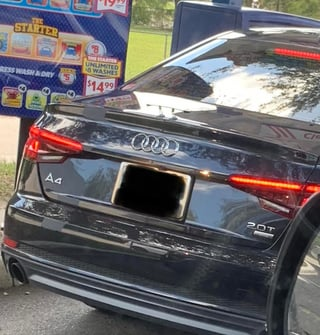

In [110]:
# Test a sample
Image.open(image_df["image_path"].iloc[0])


# Captioning (BLIP LAYER)

Generate natural-language descriptions for each image using a pretrained BLIP captioning model.

In [111]:
# Load BLIP model & processor
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").eval()


In [112]:
# Generate captions
def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = blip_processor(image, return_tensors="pt")

    with torch.no_grad():
        out = blip_model.generate(**inputs, max_new_tokens=100)

    caption = blip_processor.decode(out[0], skip_special_tokens=True)
    return caption


In [113]:
# Example captioning
print("Image:", image_df["image_path"].iloc[0])
print("Caption:", generate_caption(image_df["image_path"].iloc[0]))


Image: /content/fakeddit_images/0.jpg
Caption: a car is parked in front of a bus


In [114]:
# Generate captions for all sampled images
captions = []

for i, row in image_df.iterrows():
    cap = generate_caption(row["image_path"])
    captions.append(cap)

image_df["generated_caption"] = captions
image_df[["image_path", "clean_title", "generated_caption"]].head()


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


,image_path,clean_title,generated_caption
0,/content/fakeddit_images/0.jpg,this tiny spoiler on this car,a car is parked in front of a bus
1,/content/fakeddit_images/1.jpg,i am going to a hospital in due to notoriety o...,a man in a white suit is escorted by police
2,/content/fakeddit_images/2.jpg,flamingo bros where are my shoes,a woman sitting in a chair with a cell phone
3,/content/fakeddit_images/3.jpg,people really did buy poop on black friday,a box with a cat on it sitting on a table
4,/content/fakeddit_images/4.jpg,chips and salsa worth stolen from exeter stora...,"a box of chips with a sign that says, ' i ' m '"


# Text Similarity (SentenceTransformer Layer)

Compute semantic similarity between user-provided text and BLIP-generated captions using a pretrained SentenceTransformer model.

In [115]:
# Load SentenceTransformer
sim_model = SentenceTransformer("all-mpnet-base-v2")

In [116]:
# Get text similarity scores
def compute_similarity(text1, text2):
    emb1 = sim_model.encode(text1, convert_to_tensor=True)
    emb2 = sim_model.encode(text2, convert_to_tensor=True)
    sim = util.cos_sim(emb1, emb2).item()
    return float(sim)


In [117]:
# Display an example
t1 = image_df["clean_title"].iloc[0]
t2 = image_df["generated_caption"].iloc[0]
simt1t2 = compute_similarity(t1, t2)

print(f"User Text        : {t1}")
print(f"Generated Caption: {t2}")
print(f"Similarity Score : {simt1t2:.4f}")

User Text        : this tiny spoiler on this car
Generated Caption: a car is parked in front of a bus
Similarity Score : 0.3047


In [118]:
image_df.head()

,image_path,label,clean_title,generated_caption
0,/content/fakeddit_images/0.jpg,1,this tiny spoiler on this car,a car is parked in front of a bus
1,/content/fakeddit_images/1.jpg,0,i am going to a hospital in due to notoriety o...,a man in a white suit is escorted by police
2,/content/fakeddit_images/2.jpg,0,flamingo bros where are my shoes,a woman sitting in a chair with a cell phone
3,/content/fakeddit_images/3.jpg,1,people really did buy poop on black friday,a box with a cat on it sitting on a table
4,/content/fakeddit_images/4.jpg,1,chips and salsa worth stolen from exeter stora...,"a box of chips with a sign that says, ' i ' m '"


# Classifier (RoBERTa Prediction Layer)

Run the pretrained RoBERTa model to obtain binary fake/real predictions with confidence scores.

In [119]:
# Load RoBERTa model + tokenizer
model_name = "roberta-base-openai-detector"

roberta_tokenizer = AutoTokenizer.from_pretrained(model_name)
roberta_model = AutoModelForSequenceClassification.from_pretrained(model_name).eval()


Some weights of the model checkpoint at roberta-base-openai-detector were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [120]:
# Classification helper
def classify_with_roberta(text):
    text = text.replace("\n", " ").strip()
    inputs = roberta_tokenizer(text, return_tensors="pt", truncation=True)
    with torch.no_grad():
        outputs = roberta_model(**inputs)
        probs = F.softmax(outputs.logits, dim=1).squeeze()

    pred = torch.argmax(probs).item()
    label = "fake" if pred == 0 else "real"
    confidence = probs[pred].item()
    return label, confidence


# LLM Reasoning (GPT-4.1-mini Layer)

Use an LLM to combine predictions from user text, BLIP caption, and semantic similarity to make a final decision.

In [121]:
# LLM promt builder
def build_prompt(
        user_text, text_pred, text_conf,
        blip_caption, cap_pred, cap_conf,
        similarity_score):

    return f"""
You are a misinformation detection assistant.

Here is a news headline for an image: "{user_text}"
A text classifier predicted this text is: {text_pred}
With a confidence score of: {text_conf:.2f}

An AI-generated caption describes the same image as: "{blip_caption}"
A text classifier predicted this caption is: {cap_pred}
With a confidence score of: {cap_conf:.2f}

Cosine similarity between the headline and AI-generated caption is: {similarity_score:.2f}

Please:
1. Decide if the content is likely associated with real or fake news. Choose ONE of: Real / Fake
2. Provide a SHORT explanation (1–2 sentences).
3. Suggest ONE action the user can take.

Respond in this exact format:
- Decision:
- Explanation:
- Nudge:
"""


In [122]:
# LLM call wrapper
def query_llm(prompt):
    resp = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt,
        max_output_tokens=150,
        temperature=0
    )
    return resp.output_text


In [123]:
# Run pipeline
results = []

for i, row in image_df.iterrows():
    user_text = row["clean_title"]
    blip_caption = row["generated_caption"]

    # RoBERTa on user caption
    text_pred, text_conf = classify_with_roberta(user_text)

    # RoBERTa on BLIP caption
    cap_pred, cap_conf = classify_with_roberta(blip_caption)

    # Similarity
    sim_score = compute_similarity(user_text, blip_caption)

    # LLM reasoning
    prompt = build_prompt(
        user_text, text_pred, text_conf,
        blip_caption, cap_pred, cap_conf,
        sim_score
    )
    llm_out = query_llm(prompt)

    results.append({
        "image_path": row["image_path"],
        "text": user_text,
        "caption": blip_caption,
        "true_label": row["label"],
        "text_pred": text_pred,
        "text_conf": text_conf,
        "caption_pred": cap_pred,
        "caption_conf": cap_conf,
        "similarity": sim_score,
        "llm_response": llm_out
    })

results_df = pd.DataFrame(results)
results_df.head()


,image_path,text,caption,true_label,text_pred,text_conf,caption_pred,caption_conf,similarity,llm_response
0,/content/fakeddit_images/0.jpg,this tiny spoiler on this car,a car is parked in front of a bus,1,fake,0.839810,fake,0.731769,0.304687,- Decision: Fake \n- Explanation: The headlin...
1,/content/fakeddit_images/1.jpg,i am going to a hospital in due to notoriety o...,a man in a white suit is escorted by police,0,fake,0.968114,fake,0.749321,0.122517,- Decision: Fake \n- Explanation: Both the he...
2,/content/fakeddit_images/2.jpg,flamingo bros where are my shoes,a woman sitting in a chair with a cell phone,0,fake,0.579836,fake,0.806400,0.018064,- Decision: Fake \n- Explanation: The headlin...
3,/content/fakeddit_images/3.jpg,people really did buy poop on black friday,a box with a cat on it sitting on a table,1,real,0.889616,real,0.558209,0.132825,- Decision: Fake \n- Explanation: The headlin...
4,/content/fakeddit_images/4.jpg,chips and salsa worth stolen from exeter stora...,"a box of chips with a sign that says, ' i ' m '",1,fake,0.785687,fake,0.521320,0.366839,- Decision: Fake \n- Explanation: The headlin...


In [124]:
# LLM response parser
def parse_field(resp, key):
    m = re.search(rf"-\s*{key}\s*:\s*(.*)", resp, flags=re.IGNORECASE)
    return m.group(1).strip() if m else None

results_df["llm_decision"]    = results_df["llm_response"].apply(lambda r: parse_field(r, "Decision"))
results_df["llm_explanation"] = results_df["llm_response"].apply(lambda r: parse_field(r, "Explanation"))
results_df["llm_nudge"]       = results_df["llm_response"].apply(lambda r: parse_field(r, "Nudge"))


In [125]:
# Display the final table with parsed llm response
results_df[[
    "text",
    "caption",
    "similarity",
    "true_label",
    "text_pred",
    "caption_pred",
    "llm_decision",
    "llm_explanation",
    "llm_nudge"
]]

,text,caption,similarity,true_label,text_pred,caption_pred,llm_decision,llm_explanation,llm_nudge
0,this tiny spoiler on this car,a car is parked in front of a bus,0.304687,1,fake,fake,Fake,The headline and AI-generated caption both hav...,Verify the image and accompanying text with tr...
1,i am going to a hospital in due to notoriety o...,a man in a white suit is escorted by police,0.122517,0,fake,fake,Fake,Both the headline and AI-generated caption hav...,Verify the information by checking credible ne...
2,flamingo bros where are my shoes,a woman sitting in a chair with a cell phone,0.018064,0,fake,fake,Fake,The headline and AI-generated caption are both...,Verify the source of the image and text by cro...
3,people really did buy poop on black friday,a box with a cat on it sitting on a table,0.132825,1,real,real,Fake,The headline about people buying poop on Black...,Verify the story by checking reputable news so...
4,chips and salsa worth stolen from exeter stora...,"a box of chips with a sign that says, ' i ' m '",0.366839,1,fake,fake,Fake,The headline about stolen chips and salsa from...,Verify the story by checking trusted news sour...
...,...,...,...,...,...,...,...,...,...
220,funding boost means new koala homes among the ...,a koalaa and her baby in a basket,0.339895,1,real,real,Real,"The headline and caption both describe koalas,...",Verify the source of the funding announcement ...
221,device explodes at marine race on jersey shore...,a man is walking down the street in front of a...,-0.045494,1,fake,fake,Fake,The headline about a device explosion at a mar...,Verify the news by checking trusted local news...
222,nude woman doing yoga on a rooftop while the s...,a woman doing yoga on the beach,0.514354,1,real,fake,Fake,The headline and AI-generated caption describe...,Verify the original source of the image and cr...
223,read lenin romanian poster,a poster advertising a book with a picture of ...,0.604306,0,fake,real,Real,The AI-generated caption accurately describes ...,Verify the source and context of the poster to...


# Evaluation (Metrics & Visualizations)

Compute accuracy, confusion matrices, and classification reports for classifiers and LLM outputs, and review similarity matrices.

In [126]:
# Convert textual labels to ints
def label_to_int(x):
    if str(x).lower() == "fake":  return 0
    if str(x).lower() == "real":  return 1
    return None  # Unclear or invalid

results_df["true_label"] = results_df["true_label"].astype(int)
results_df["text_label"] = results_df["text_pred"].apply(label_to_int)
results_df["caption_label"] = results_df["caption_pred"].apply(label_to_int)
results_df["llm_label"] = results_df["llm_decision"].apply(label_to_int)

# Clean unclear or invalid LLM decisions (if any)
llm_clean = results_df.dropna(subset=["llm_label"])

In [127]:
# Accuracies
text_acc = np.mean(results_df["text_label"] == results_df["true_label"])
cap_acc = np.mean(results_df["caption_label"] == results_df["true_label"])
llm_acc  = np.mean(llm_clean["llm_label"] == llm_clean["true_label"])
llm_cov  = len(llm_clean) / len(results_df)

print("User text classifier accuracy:", round(text_acc, 3))
print("BLIP caption classifier accuracy:", round(cap_acc, 3))
print("LLM accuracy:", round(llm_acc, 3))
print("LLM coverage:", round(llm_cov, 3))


User text classifier accuracy: 0.502
BLIP caption classifier accuracy: 0.431
LLM accuracy: 0.462
LLM coverage: 1.0


In [128]:
# Confusion matrices

# User text classifier CM
text_cm = confusion_matrix(results_df["true_label"], results_df["text_label"])

# BLIP caption classifier CM
cap_cm = confusion_matrix(results_df["true_label"], results_df["caption_label"])

# LLM classifier CM
llm_cm = confusion_matrix(llm_clean["true_label"], llm_clean["llm_label"])

print("RoBERTa (Text) Confusion Matrix:\n", text_cm)
print("\nRoBERTa (Caption) Confusion Matrix:\n", cap_cm)
print("\nGPT (Combined) Confusion Matrix:\n", llm_cm)

RoBERTa (Text) Confusion Matrix:
 [[49 26]
 [86 64]]

RoBERTa (Caption) Confusion Matrix:
 [[ 64  11]
 [117  33]]

GPT (Combined) Confusion Matrix:
 [[ 64  11]
 [110  40]]


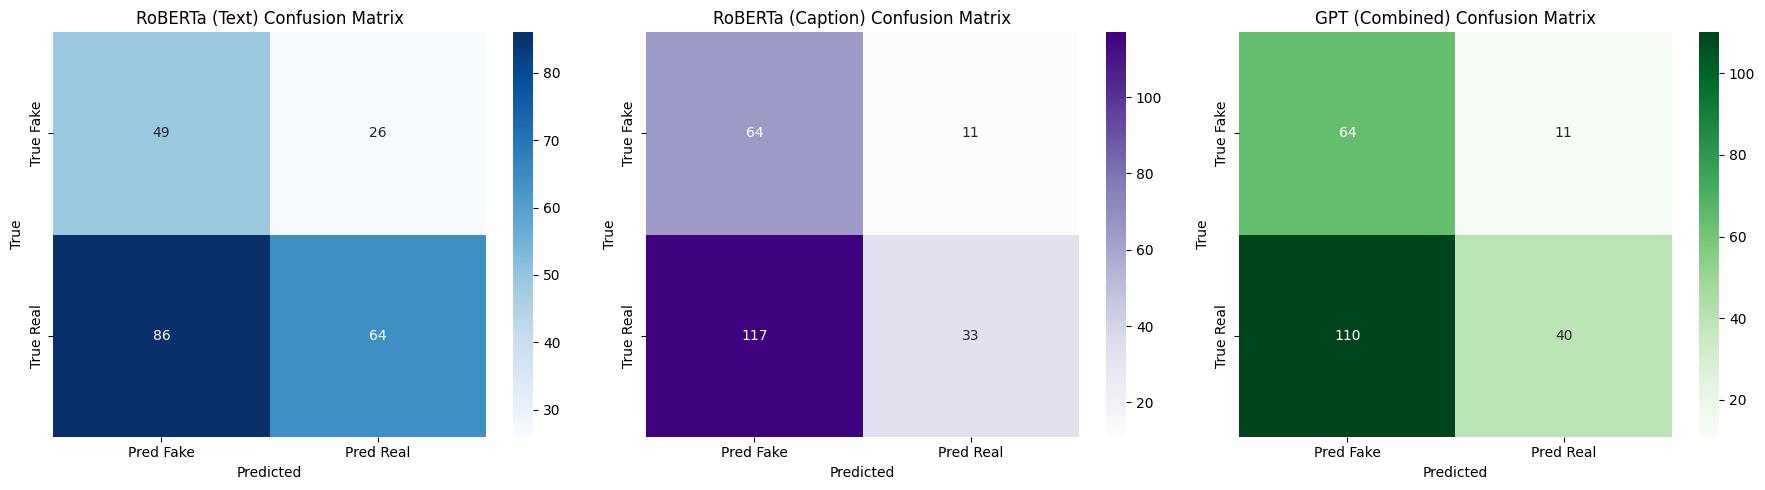

In [129]:
# Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(text_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[0])
axes[0].set_title("RoBERTa (Text) Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cap_cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[1])
axes[1].set_title("RoBERTa (Caption) Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

sns.heatmap(llm_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred Fake", "Pred Real"],
            yticklabels=["True Fake", "True Real"],
            ax=axes[2])
axes[2].set_title("GPT (Combined) Confusion Matrix")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")

plt.tight_layout()
plt.show()

In [130]:
# Classification reports
print("\n-----------------------------------------------------")
print("RoBERTa (Text) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    results_df["true_label"],
    results_df["text_label"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("RoBERTa (Caption) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    results_df["true_label"],
    results_df["caption_label"],
    target_names=["Fake", "Real"]
))

print("\n-----------------------------------------------------")
print("GPT (Combined) Classification Report:")
print("-----------------------------------------------------")
print(classification_report(
    llm_clean["true_label"],
    llm_clean["llm_label"],
    target_names=["Fake", "Real"]
))



-----------------------------------------------------
RoBERTa (Text) Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.36      0.65      0.47        75
        Real       0.71      0.43      0.53       150

    accuracy                           0.50       225
   macro avg       0.54      0.54      0.50       225
weighted avg       0.60      0.50      0.51       225


-----------------------------------------------------
RoBERTa (Caption) Classification Report:
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.35      0.85      0.50        75
        Real       0.75      0.22      0.34       150

    accuracy                           0.43       225
   macro avg       0.55      0.54      0.42       225
weighted avg       0.62      0.43      0.39       225


------------------------------------------------

In [136]:
# Sample N pairs randomly for a clear similarity matrix visualization
Nsub = 20
subset_df = results_df.sample(Nsub, random_state=42).reset_index(drop=True)


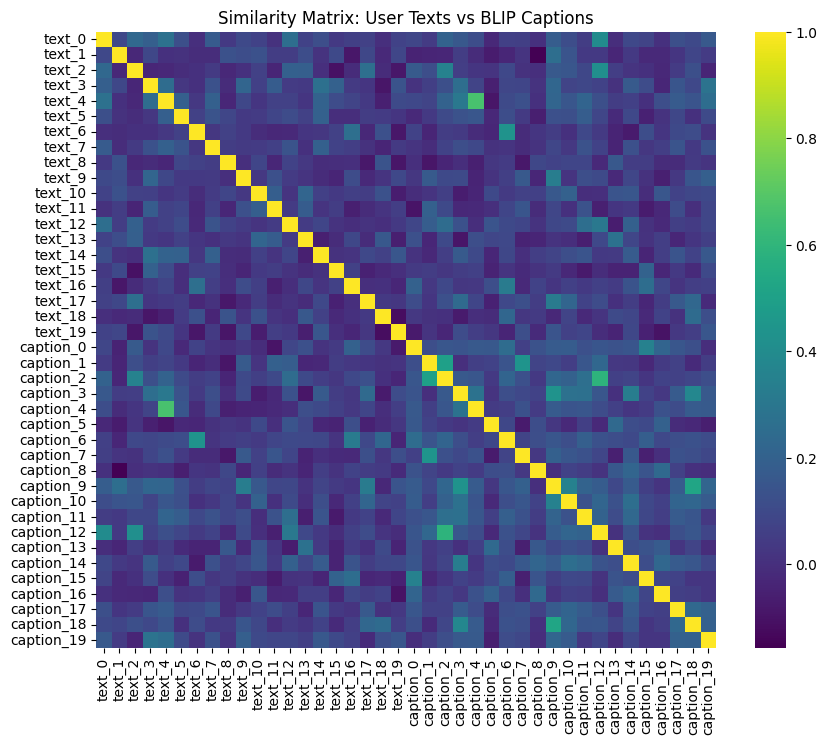

In [137]:
# Similarity matrix
texts = list(subset_df["text"]) + list(subset_df["caption"])
labels = (
    ["text_"+str(i) for i in range(len(subset_df))] +
    ["caption_"+str(i) for i in range(len(subset_df))]
)

# Compute embeddings
embs = sim_model.encode(texts, convert_to_tensor=True)

# Compute similarity matrix
sim_matrix = util.cos_sim(embs, embs).cpu().numpy()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, cmap="viridis", xticklabels=labels, yticklabels=labels)
plt.title("Similarity Matrix: User Texts vs BLIP Captions")
plt.show()


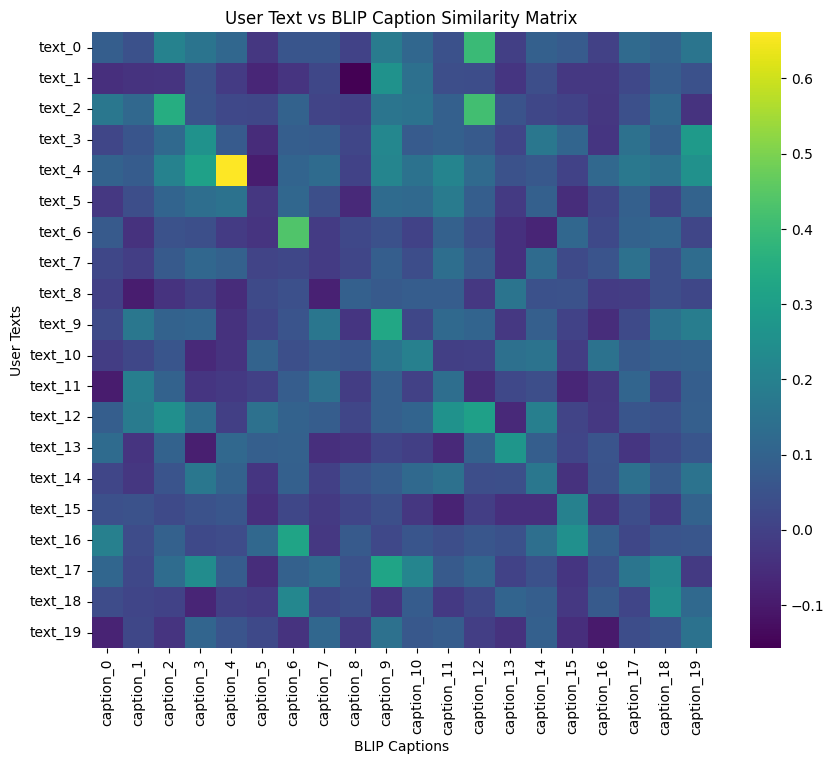

In [135]:
# Similarity matrix (1-1 compact)
user_texts = list(subset_df["text"])
blip_caps = list(subset_df["caption"])

# Encode separately
user_embs = sim_model.encode(user_texts, convert_to_tensor=True)
blip_embs = sim_model.encode(blip_caps, convert_to_tensor=True)

# Compute pairwise similarity (Users × BLIPs)
uvb_matrix = util.cos_sim(user_embs, blip_embs).cpu().numpy()

# Labels
user_labels = [f"text_{i}" for i in range(len(user_texts))]
blip_labels = [f"caption_{i}" for i in range(len(blip_caps))]

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(uvb_matrix, annot=False, cmap="viridis",
            xticklabels=blip_labels, yticklabels=user_labels)
plt.title("User Text vs BLIP Caption Similarity Matrix")
plt.xlabel("BLIP Captions")
plt.ylabel("User Texts")
plt.show()


In [165]:
# Extract the scores for the paired items (the diagonal)
diagonal_scores = np.diag(uvb_matrix)

# Find the index of the maximum score (Most Aligned)
max_index = np.argmax(diagonal_scores)

# Find the index of the minimum score (Most Misaligned)
min_index = np.argmin(diagonal_scores)


# 4. Print the result for the most aligned pair
print("\n-----------------------------------------------------")
print("Most Aligned Pair (Highest Semantic Score)")
print("-----------------------------------------------------")
print(f"Score        : {diagonal_scores.max():.4f}")
print(f"Index        : {max_index}")
print(f"User Text    : '{user_texts[max_index]}'")
print(f"BLIP Caption : '{blip_caps[max_index]}'")


# 5. Print the result for the most misaligned pair
print("\n-----------------------------------------------------")
print("Most Misaligned Pair (Lowest Semantic Score)")
print("-----------------------------------------------------")
print(f"Score        : {diagonal_scores.min():.4f}")
print(f"Index        : {min_index}")
print(f"User Text    : '{user_texts[min_index]}'")
print(f"BLIP Caption : '{blip_caps[min_index]}'")



-----------------------------------------------------
Most Aligned Pair (Highest Semantic Score)
-----------------------------------------------------
Score        : 0.6614
Index        : 4
User Text    : 'this red sunset'
BLIP Caption : 'a sunset with a tree in the fore'

-----------------------------------------------------
Most Misaligned Pair (Lowest Semantic Score)
-----------------------------------------------------
Score        : -0.0369
Index        : 1
User Text    : 'boise parks and rec to employ the homeless'
BLIP Caption : 'a group of people sitting around a table'


**Observations on the Results**

- **RoBERTa (Text)** reaches 50% accuracy. It shows higher recall for fake headlines (0.65) than for real ones (0.43), with precision 0.36 (fake) and 0.71 (real). This suggests a tendency to over-flag ambiguous items as fake; it catches many fake samples, but at the cost of misclassifying a non-trivial number of real ones.

- **RoBERTa (Caption)** performs slightly worse overall (43% accuracy). Recall for fake items is high (0.85), but recall for real items is very low (0.22), meaning the caption-only classifier is strongly biased toward "fake" when working on BLIP descriptions. This confirms that AI-generated captions alone are a weak signal for distinguishing real vs fake news.

- **GPT (Combined)** achieves 46% accuracy. It keeps a very high recall for fake items (0.85) and improves fake precision a bit (0.37), but recall for real items remains low (0.27). In other words, the fusion of user text, BLIP caption, classifier outputs, and similarity scores pushes the LLM toward conservative "fake" decisions rather than balancing both classes.

**Overall,** this fusion setup still struggles to recover real items reliably. Combining two noisy textual views and a similarity score helps the model stay sensitive to fake content but reinforces a fake bias instead of denoising it. This points to the need for better-calibrated signals (e.g., stronger baselines, different prompts) and/or richer multimodal information beyond text–text fusion.
